# Modelos

> Modelo base : Naive estacional

> Modelo experimentos : SARIMA

In [138]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error as rmse
from statsforecast.models import ARIMA
from statsforecast import StatsForecast
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

import sys
sys.path.append('..')

from utils.estacionariedad import prueba_diferenciacion
from utils.parametros_ARIMA import pacf_acf
from utils.metricas_cv import metricas_cv

In [139]:
df = pd.read_csv('../datos/df_01.csv',
                parse_dates = ['fecha'],
                index_col = 'fecha')
df.head()

,value
fecha,
2019-01-01 00:00:00,23216.0
2019-01-01 01:00:00,24947.0
2019-01-01 02:00:00,27655.0
2019-01-01 03:00:00,27676.0
2019-01-01 04:00:00,26853.0


### Preparar formato 

In [140]:
df = df.reset_index()                   
df.columns = ['ds', 'y']                      
df['unique_id'] = 'serie1'
df = df[['unique_id', 'ds', 'y']]
df

,unique_id,ds,y
0,serie1,2019-01-01 00:00:00,23216.0
1,serie1,2019-01-01 01:00:00,24947.0
2,serie1,2019-01-01 02:00:00,27655.0
3,serie1,2019-01-01 03:00:00,27676.0
4,serie1,2019-01-01 04:00:00,26853.0
...,...,...,...
57404,serie1,2025-07-19 20:00:00,29380.0
57405,serie1,2025-07-19 21:00:00,27763.0
57406,serie1,2025-07-19 22:00:00,26659.0
57407,serie1,2025-07-19 23:00:00,26438.0


### Modelo Seasonal Naive

In [141]:
H = 24
df_train_naive = df.iloc[:-H]['y'].copy()
df_test_naive = df.iloc[-H:]['y'].copy()

df_pred_naive = df_train_naive.shift(H)

mape_base = mape(df_train_naive[H:], df_pred_naive[H:])
rmse_base = rmse(df_train_naive[H:], df_pred_naive[H:])

print('> Medidas desempeño --- Seasonal Naive')
print(f'MAPE: {100*mape_base:.4f}')
print(f'RMSE: {rmse_base:.4f}')

> Medidas desempeño --- Seasonal Naive
MAPE: 5.0687
RMSE: 1821.9338


### Modelo SARIMA
* Una sola variable
* Tendencia y varianza constantes
* Serie estacionaria (?)

### Selección del mejor modelo SARIMA

Basándome en el comportamiento del ACF, PACF obtenidos en el EDA:

| Parámetro | Valor | Fuente | Razón |
|-----------|-------|--------|-------|
| p | 2 | PACF regular | Corte brusco tras lag 2 |
| d | 0 | Dickey-Fuller (sin diferencia) | Serie ya estacionaria |
| q | 0 | ACF regular | No hay corte brusco |
| P | 1 | PACF estacional (lag 24) | Un pico significativo en lag 24 |
| D | 1 | ACF estacional | Picos en 24/48/72 decaen lento |
| Q | 0 | ACF estacional | No hay corte brusco en lags estacionales |
| s | 24 | Ambas (ACF/PACF) | Picos en 24, 48, 72... |

In [142]:
ps = [0, 1, 2]
d  = 0
q  = 0
Ps = [0, 1]
Ds = [0, 1]
Q  = 0

modelos = [ARIMA(order=(p, d, q), seasonal_order=(P, D, Q), 
                season_length=24,
                alias=f'ARIMA({p},{d},{q})({P},{D},{Q})_24',
                include_constant=False)
                for p in ps
                for P in Ps
                for D in Ds] 

sf = StatsForecast(
    models = modelos,
    freq = 'h',
    n_jobs = -1
)

print(f'Se crearon {len(modelos)} modelos')
modelos

Se crearon 12 modelos


[ARIMA(0,0,0)(0,0,0)_24,
 ARIMA(0,0,0)(0,1,0)_24,
 ARIMA(0,0,0)(1,0,0)_24,
 ARIMA(0,0,0)(1,1,0)_24,
 ARIMA(1,0,0)(0,0,0)_24,
 ARIMA(1,0,0)(0,1,0)_24,
 ARIMA(1,0,0)(1,0,0)_24,
 ARIMA(1,0,0)(1,1,0)_24,
 ARIMA(2,0,0)(0,0,0)_24,
 ARIMA(2,0,0)(0,1,0)_24,
 ARIMA(2,0,0)(1,0,0)_24,
 ARIMA(2,0,0)(1,1,0)_24]

In [143]:
H = 24
df_train = df.iloc[:-H].copy()
df_test = df.iloc[-H:].copy()

### Validación cruzada con una ventana fija

In [144]:
cv_rolling = sf.cross_validation(
    df = df_train,
    h = 24, 
    step_size = 48,
    n_windows = 15,
    input_size = 168 # entrena 7 días
    )

In [145]:
cv_rolling

,unique_id,ds,cutoff,y,"ARIMA(0,0,0)(0,0,0)_24","ARIMA(0,0,0)(0,1,0)_24","ARIMA(0,0,0)(1,0,0)_24","ARIMA(0,0,0)(1,1,0)_24","ARIMA(1,0,0)(0,0,0)_24","ARIMA(1,0,0)(0,1,0)_24","ARIMA(1,0,0)(1,0,0)_24","ARIMA(1,0,0)(1,1,0)_24","ARIMA(2,0,0)(0,0,0)_24","ARIMA(2,0,0)(0,1,0)_24","ARIMA(2,0,0)(1,0,0)_24","ARIMA(2,0,0)(1,1,0)_24"
0,serie1,2025-06-20 01:00:00,2025-06-20,29138.0,0.0,33844.0,33766.952092,34043.441070,28488.206780,30275.886524,30089.015898,30104.544675,2.881046e+04,29807.128290,29436.244117,29543.875019
1,serie1,2025-06-20 02:00:00,2025-06-20,30352.0,0.0,35499.0,35418.184384,35699.156939,28460.440649,32002.313986,31632.302684,31816.899232,2.898294e+04,31441.623567,30593.127685,31086.411633
2,serie1,2025-06-20 03:00:00,2025-06-20,31662.0,0.0,36124.0,36041.761534,36306.832912,28432.701580,32697.311594,32222.894230,32527.656446,2.906225e+04,32199.486454,30994.870448,31801.592063
3,serie1,2025-06-20 04:00:00,2025-06-20,31344.0,0.0,36024.0,35941.989190,36219.432204,28404.989547,32665.907970,32142.861178,32463.651678,2.907049e+04,32290.096996,30839.510977,31805.435771
4,serie1,2025-06-20 05:00:00,2025-06-20,31020.0,0.0,35018.0,34938.279410,35189.379010,28377.304524,31727.131166,31224.813006,31552.422875,2.902460e+04,31491.558836,29936.186711,31011.434785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,serie1,2025-07-18 20:00:00,2025-07-18,31447.0,0.0,31199.0,31129.748218,31064.079929,30396.837008,31368.178184,31014.739545,30792.095003,1.272515e+06,31200.746200,29889.664734,30538.281157
356,serie1,2025-07-18 21:00:00,2025-07-18,31102.0,0.0,30878.0,30809.460735,30761.779730,30375.093038,31041.871745,30696.661905,30533.087971,-1.334599e+06,30879.653034,29577.667108,30304.338369
357,serie1,2025-07-18 22:00:00,2025-07-18,31182.0,0.0,30600.0,30532.077806,30553.954253,30353.364623,30758.731747,30418.652811,30496.455774,1.396683e+06,30601.564838,29302.523950,30337.560047
358,serie1,2025-07-18 23:00:00,2025-07-18,30418.0,0.0,31249.0,31179.637234,31127.250219,30331.651751,31402.752971,31000.324683,30879.062181,-1.458767e+06,31250.481348,29812.288778,30660.942107


In [146]:
alias_modelos = [m.alias for m in modelos]
metricas_sarimas = metricas_cv(cv_rolling, alias_modelos)
metricas_sarimas

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,"ARIMA(0,0,0)(0,0,0)_24",28240.958911,100.000000,28060.902778,2153.679462,0.000000,2116.980365
2,"ARIMA(0,0,0)(0,1,0)_24",1702.537012,4.953038,1393.752778,724.619238,2.152238,568.263170
3,"ARIMA(0,0,0)(1,0,0)_24",1705.971711,4.948942,1394.654314,707.278495,2.052434,545.988027
4,"ARIMA(0,0,0)(1,1,0)_24",1695.858873,4.938834,1400.040878,826.745681,2.385907,681.597075
5,"ARIMA(1,0,0)(0,0,0)_24",3467.116084,10.869370,2938.623371,772.942974,2.549115,746.345868
6,"ARIMA(1,0,0)(0,1,0)_24",1711.476249,5.420722,1469.538413,1240.513865,4.394844,1158.283479
7,"ARIMA(1,0,0)(1,0,0)_24",1873.522774,6.026399,1632.837488,1155.762919,3.955266,1058.213832
8,"ARIMA(1,0,0)(1,1,0)_24",1532.829590,4.706801,1294.373446,923.508482,2.854239,803.362288
9,"ARIMA(2,0,0)(0,0,0)_24",64774.710087,198.008701,56976.291708,234820.928648,716.658483,207450.404321
10,"ARIMA(2,0,0)(0,1,0)_24",1438.253437,4.403424,1210.291308,943.034763,2.989172,822.698736


In [147]:
metricas_sarimas.sort_values(by = 'RMSE', ascending = True)[:3]

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
10,"ARIMA(2,0,0)(0,1,0)_24",1438.253437,4.403424,1210.291308,943.034763,2.989172,822.698736
8,"ARIMA(1,0,0)(1,1,0)_24",1532.829590,4.706801,1294.373446,923.508482,2.854239,803.362288
12,"ARIMA(2,0,0)(1,1,0)_24",1556.008565,4.719378,1301.763935,881.617326,2.772514,775.952777


### Búsqueda en 2 fases: Ahora encontrar el mejor tamaño de ventana
El supuesto es que el mejor modelo no cambia según la ventana de entrenamiento:

* Los parámetros p, P, q, Q dependen de la estructura de la serie, no del tamaño del entrenamiento.
* La ventana afecta cuanta historia uso, no que estructura estoy capturando.

    > La base es el modelo **ARIMA(2,0,0)(0,1,0)_24**

In [148]:
VENTANAS_HORAS = [24*7, 24*15, 24*30, 24*60, 24*90, 24*120] 
H = 24  
serie = df_train.copy()
resultados = []

p = 2
d = 0
q = 0
P = 0
D = 1
Q = 0

for ventana in VENTANAS_HORAS:
    n_windows = min(15, (ventana - H)// 48)
    print(f"\nEvaluando ventana: {ventana} h ({ventana//24} días)")
    
    modelos = [ARIMA(order=(p, d, q), seasonal_order=(P, D, Q), 
                    season_length=24,
                    alias=f'ARIMA({p},{d},{q})({P},{D},{Q})_24',
                    include_constant=False)
                ] 

    sf = StatsForecast(
        models = modelos,
        freq = 'h',
        n_jobs = -1
    )

    cv_rolling = sf.cross_validation(
    df = df_train,
    h = H, 
    step_size = 48,
    n_windows = n_windows,
    input_size = ventana
    )

    alias_modelos = [m.alias for m in modelos]
    metricas_sarimas = metricas_cv(cv_rolling, alias_modelos)
    metricas_sarimas['ventana_dias'] = ventana // 24  
    resultados.append(metricas_sarimas)


resultados = pd.concat(resultados, ignore_index=True)
resultados.sort_values('RMSE')


Evaluando ventana: 168 h (7 días)

Evaluando ventana: 360 h (15 días)

Evaluando ventana: 720 h (30 días)

Evaluando ventana: 1440 h (60 días)

Evaluando ventana: 2160 h (90 días)

Evaluando ventana: 2880 h (120 días)


,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD,ventana_dias
1,"ARIMA(2,0,0)(0,1,0)_24",1283.512326,3.452101,1016.710256,1031.353282,2.593755,790.085702,15
5,"ARIMA(2,0,0)(0,1,0)_24",1309.190202,3.736494,1044.275065,817.969202,2.263459,662.445414,120
4,"ARIMA(2,0,0)(0,1,0)_24",1334.339440,3.861359,1077.001657,828.132351,2.326007,675.380619,90
3,"ARIMA(2,0,0)(0,1,0)_24",1348.023499,3.962862,1103.119231,853.230159,2.422104,702.541562,60
2,"ARIMA(2,0,0)(0,1,0)_24",1386.216707,4.142632,1153.330567,901.776613,2.644593,756.834178,30
0,"ARIMA(2,0,0)(0,1,0)_24",1481.380677,3.818853,1142.030664,1427.711527,3.361902,1032.615883,7


| MEDIDA | NAIVE | Diferencia 15 días | Diferencia 120 días | 
|-----------|-------|--------|-------|
| RMSE | 1821.9338 MWH | 538.4214 MWH| 512.743598 MWH|
| MAPE | 5.0687 % | 3.4521 % | 1.6165 % | 1.3322 % |

Esto es lo obtenido del mejor modelo con ventanas de entrenamiento muy diferentes. Pero para la desición final, no nos podemos guiar unicamente en las medidas de deseméño, asi que ahora se va a hacer un análisis en los residuales de la predicción del tipo **'in-sample'**

### Análisis de residuales

Para analizarlos hay que tener en cuenta lo siguiente de los resúmenes que se van a obtener:

1. Ljung-Box — autocorrelación en residuales 

    La vamos a usar para saber si los residuales se comportan como ruido blando o el modelo no capturó toda la estructura temporal
    - p > 0.05 = residuales sin autocorrelación 
    - p < 0.05 = aún hay estructura no capturada 

2. Jarque-Bera — normalidad de residuales

    ¿Los errores siguen una distribución normal? 

    - p > 0.05 = residuales normales 
    - p < 0.05 = no normales y se nota más con Skew y Kurtosis

3.  Skew — asimetría

    Nos dice que tan simetrica es la distribución de los errores, la referencia es la Normal con 0.

    - |Skew| < 0.5 = aceptable 
    - |Skew| > 1 = distribución muy asimétrica 

4. Kurtosis — colas de la distribución

    Dice si la distribución tiene sesgo positivo o negativo, lareferencia es la Normal = 3.

    - Kurtosis ≈ 3 = normal 
    - Kurtosis >> 3 = colas pesadas y pueden haber outliers influyentes 

5. Prob(H) — heteroscedasticidad

    Los errores graficados no deben presentar ningún patrón visible

    - p > 0.05 → varianza constante (homocedasticidad) 
    - p < 0.05 → varianza cambia en el tiempo, por lo que hay un patron


#### Ventana de 15 días 

Media de los residuos: 21.9435
Desviación estándar: 511.1120


Text(0.5, 1.0, 'Residuales de la ventana de 15 dias')

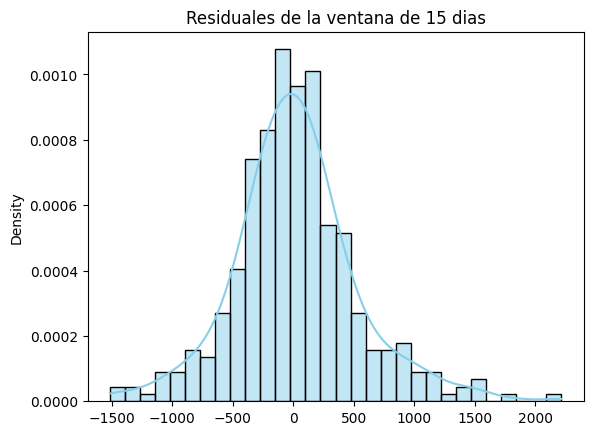

In [161]:
p = 2
d = 0
q = 0
P = 1
D = 0
Q = 0


m = 24  
VENTANA = m*15
serie = df_train.copy()
resultados = []

train_ventana = df_train['y'][-(VENTANA + H):-H]
val_ventana = df_train['y'][-H:]

modelo = SARIMAX(train_ventana, order=(p,d,q), seasonal_order=(P,D,Q,m)).fit(disp=False)
pred_is = modelo.predict()

residuales = train_ventana.values[1:] - pred_is.values[1:]

print(f"Media de los residuos: {residuales.mean():.4f}")
print(f"Desviación estándar: {residuales.std():.4f}")

sns.histplot(residuales, kde=True, stat="density", bins=30, color="skyblue")
plt.title(f'Residuales de la ventana de {VENTANA//24} dias')

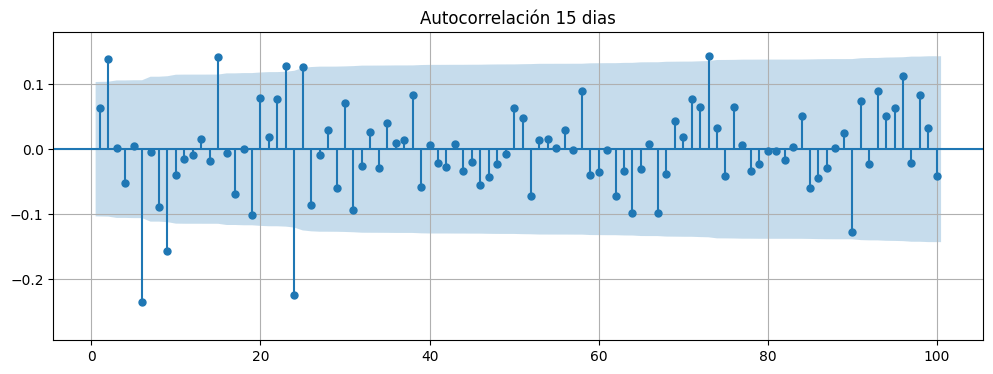

In [162]:
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(residuales, lags=100, zero=False, auto_ylims=True, ax=ax)
plt.title(f'Autocorrelación {VENTANA//m} dias')
ax.grid(True)

In [151]:
print(f"Tamaño train_ventana: {len(train_ventana)}")  
print(modelo.summary())
train_ventana = df_train['y'][-(VENTANA + H):-H]

Tamaño train_ventana: 360
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  360
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 24)   Log Likelihood               -2743.758
Date:                            Sat, 16 May 2026   AIC                           5495.516
Time:                                    17:33:12   BIC                           5511.061
Sample:                                         0   HQIC                          5501.697
                                            - 360                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2668      0.044     29.037      0.000       1.181       1.352
ar.L2    

#### Ventana de 120

Media de los residuos: 0.5985
Desviación estándar: 584.3323


Text(0.5, 1.0, 'Residuales de la ventana de 120 dias')

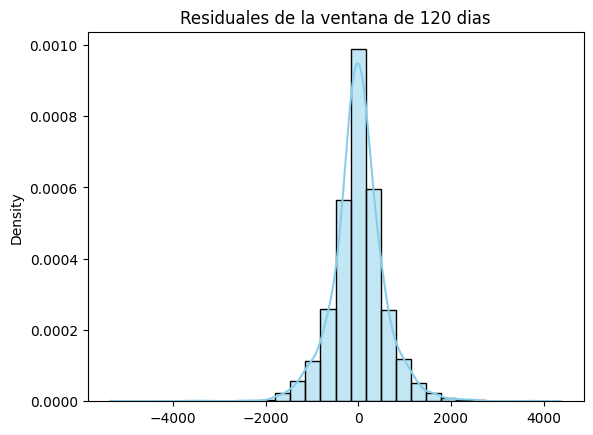

In [158]:
p = 2
d = 0
q = 0
P = 1
D = 0
Q = 0

m = 24  
VENTANA = m*120
serie = df_train.copy()
resultados = []

train_ventana = df_train['y'][-(VENTANA + H):-H]
val_ventana = df_train['y'][-H:]

modelo = SARIMAX(train_ventana, order=(p,d,q), seasonal_order=(P,D,Q,m)).fit(disp=False)
pred_is = modelo.predict()

residuales = train_ventana.values[1:] - pred_is.values[1:]

print(f"Media de los residuos: {residuales.mean():.4f}")
print(f"Desviación estándar: {residuales.std():.4f}")

sns.histplot(residuales, kde=True, stat="density", bins=30, color="skyblue")
plt.title(f'Residuales de la ventana de {VENTANA//m} dias')

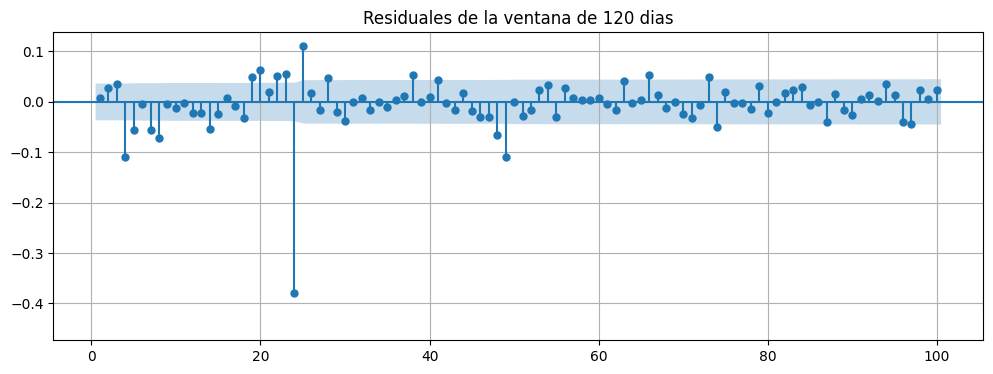

In [160]:
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(residuales, lags=100, zero=False, auto_ylims=True, ax=ax)
plt.title(f'Residuales de la ventana de {VENTANA//m} dias')
ax.grid(True)

In [154]:
print(f"Tamaño train_ventana: {len(train_ventana)}")  
print(modelo.summary())
train_ventana = df_train['y'][-(VENTANA + H):-H]

Tamaño train_ventana: 2880
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2880
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 24)   Log Likelihood              -22674.257
Date:                            Sat, 16 May 2026   AIC                          45356.514
Time:                                    17:33:16   BIC                          45380.376
Sample:                                         0   HQIC                         45365.115
                                           - 2880                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1502      0.016     70.523      0.000       1.118       1.182
ar.L2   

### Pronóstico con el set de pruebas